## Machine Learning for Quantitative Investing Academy Project


This project develops a systematic equity portfolio strategy that combines momentum investing with machine-learning based stock selection. The goal is to improve the stock selection of a momentum based model using additional information about risk, consistency and relative performance.

**A note on the stock universe:** the strategy is tested on a broad, hand-picked list of large-cap stocks rather than a full point-in-time reconstruction of a historical index. This means some survivorship bias likely remains — companies that were delisted, went bankrupt, or fell out of the large-cap universe over the backtest period are not included — so absolute return figures throughout this notebook should be read as an upper bound rather than a realistic forecast. This is discussed in more depth later in the notebook.

## **Each month, we:**


*   Compute a multi-horizon momentum score for all stocks in the universe using 1,3,6 and 12 month returns.
*   Rank all stocks by this score and retain the top 30 momentum stocks as candidates.
*   For each of these 30 stocks, use a Random Forest regression model to rank stocks by expected return
*   Select the top 15 stocks with the highest ranks from these 30.
*   Allocate capital across these 15 stocks using Sharpe ratio based weights.
*   We then rebalance the portfolio monthly applying transaction costs based on portfolio turnover.


Stock momentum is a measure of a stock's recent price performance, and is used to filter candidate stocks for inclusion in the portfolio.

We will compute momentum across multiple horizons to capture both short-term and
long-term trends while reducing sensitivity to noise.

Let $P_{i,t}$ denote the price of stock $i$ at time $t$.
The return over a lookback window of $L$ trading days is:

For stock $i$ at time $t$, the return over a lookback window of $L$ trading days is:

$$
r_{i,t}^{(L)} = \frac{P_{i,t}}{P_{i,t-L}} - 1
$$

We combine four momentum horizons using fixed weights:

- 252 trading days (12 months)
- 126 trading days (6 months)
- 63 trading days (3 months)
- 21 trading days (1 month)

The final momentum score is defined as:

$$
\text{Momentum}_{i,t}
= 0.4\,r_{i,t}^{(252)}
+ 0.3\,r_{i,t}^{(126)}
+ 0.2\,r_{i,t}^{(63)}
+ 0.1\,r_{i,t}^{(21)}
$$


Multi-horizon momentum is better than a single horizon because it diversifies trend signals across time, making the signal more stable and robust to regime changes. Longer lookbacks (252, 126) get higher weights because their momentum is more persistent and less noisy, while shorter horizons (63, 21) adapt faster but are more volatile. The declining weights balance reliability first, responsiveness second.

Each month, stocks are ranked by this score and the top 30 are retained as
candidates for machine learning selection.

---

## Machine Learning Stock Selection

Machine learning is used to refine stock selection within the momentum universe
rather than to replace momentum entirely.

For each of the top 30 momentum stocks, we compute features designed to capture
return persistence, volatility, and stability.

## Feature Set

### Multi-horizon returns:

$$
r_{21},\; r_{63},\; r_{126},\; r_{252}
$$

 - These measure the stock's cumulative return over the past 1, 3, 6, and 12 months respectively. Using multiple horizons allows the model to observe both short-term and longer-term trends, rather than relying on a single lookback window.

### Annualised volatility over the last 63 trading days:

$$
\sigma_{63} = \sqrt{252}\,\text{std}(r_{\text{daily}})
$$

 - The formula above calculates the standard deviation of daily returns over the last 63 trading days and scales it to an annual level by multiplying by the square root of 252.

 (We note that Var(T-day return)=T×Var(daily return) )

### Volatility trend:

$$
\sigma_{21} - \sigma_{63}
$$

 - This captures whether volatility is increasing or decreasing. A positive value indicates that recent volatility is higher than its long term average, which may signal rising uncertainty or instability.

### Maximum drawdown over the last 12 months:

$$
\text{DD}_t = \frac{P_t}{\max(P_{t-252:t})} - 1
$$

 - This measures how far the current price is below its largest peak in the last 12 months. Large negative drawdowns indicate that the stock has experienced significant losses, even if recent momentum is strong.

### Momentum consistency:

 - Defined as the fraction of positive monthly returns over the last 6 months. Stocks with recent positive performance may be more reliable than those whose returns are driven by a small number of large moves.

### Relative strength:

 - Defined as the stock's 63-day return minus the cross-sectional average 63-day return. It measures whether the stock is outperforming the broader market rather than rising due to overall market conditions.


### Return skewness over the last 63 trading days:

 - Skewness measures the asymmetry of returns, negative skewness indicates a higher probability of large downside moves, which is undesirable from a risk-management perspective.


---


# Random Forest


The Random Forest model is trained to predict each stock's cross-sectional rank of forward monthly return (0 to 1 percentile) relative to its candidate peers that month, rather than the raw return itself. This makes the target more stable across different market regimes, since a given return level can mean very different things depending on whether the broader market is rallying or falling, ranking within the same month isolates relative performance from overall market direction.


---


## Portfolio Construction

The classical Sharpe ratio is $S = \frac{R_p - R_f}{\sigma_p}$, where $R_p$ is the expected portfolio return, $R_f$ is the risk-free rate, and $\sigma_p$ is the portfolio volatility. In our strategy, we assume $R_f = 0$ (since daily risk-free rate is tiny), so each stock $i$ is weighted using a Sharpe-like score $\frac{\mu_i}{\sigma_i}$, where $\mu_i$ and $\sigma_i$ are the mean and standard deviation of recent daily returns.

Selected stocks are weighted using Sharpe-ratio-based allocations:

$$
w_i \propto \frac{\mu_i}{\sigma_i}
$$

where $\mu_i$ and $\sigma_i$ denote the mean and standard deviation of recent
daily returns. Portfolio weights are normalised to sum to one.

Portfolios are rebalanced monthly. Transaction costs of 0.1% per unit of
portfolio turnover are applied, where turnover is defined as the sum of
absolute changes in portfolio weights between rebalancing dates.

# Importing:

We first import the libraries we need.

In [16]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")



We then import the stock data and define the number of candidates and the final number of firms, as well as the time frames we wish to train and backtest on.

In [17]:
DOWNLOAD_START = "2009-01-01"
TRAIN_START    = "2010-01-01"
TRAIN_END      = "2021-12-31"
BACKTEST_START = "2022-01-01"
BACKTEST_END   = "2025-12-31"
RETRAIN_MONTHS = 6

CANDIDATES     = 30    # momentum pre-filter: top 30 stocks
TOP_N          = 15    # ML picks best 15 from the 30 candidates
TRANSACTION_COST = 0.001
LOOKBACKS      = {252: 0.4, 126: 0.3, 63: 0.2, 21: 0.1}

# ============================================================
# TICKERS
# ============================================================
# Sector-stratified sample of ~180 current S&P 500 constituents (source:
# Wikipedia "List of S&P 500 companies", GICS sector tags), sampled in
# proportion to each sector's actual weight in the index rather than
# hand-picked by name. A handful of the largest names per sector (e.g.
# NVDA, AAPL, AVGO, TSLA) are guaranteed to be included so the sample
# can't accidentally miss an obvious mega-cap the way a hand-typed list
# can. Note this still only pulls from companies in the index *today* --
# it fixes the sector/recency selection bias of the old hand-typed list,
# but it does not fix survivorship bias (see the Survivorship Bias
# section below).
tickers = [
    "A","AAPL","ADP","AEE","AIZ","AJG","AKAM","ALGN","AMAT","AME",
    "AMP","AMT","AMZN","APH","APTV","ATO","AVB","AVGO","AXON","AXP",
    "BA","BAC","BBY","BEN","BIIB","BKNG","BKR","BR","BRK-B","BRO",
    "BSX","C","CAT","CBRE","CCI","CCL","CEG","CHRW","CHTR","CL",
    "CMI","CMS","COP","CPB","CPT","CRL","CSCO","CSGP","CSX","CTAS",
    "CVX","DG","DGX","DHR","DIS","DLTR","DTE","ECL","EPAM","EQR",
    "ERIE","ETN","ETR","EXE","EXR","FCX","FE","FISV","FIX","FOX",
    "FSLR","FTNT","FTV","GDDY","GE","GEV","GM","GOOGL","GPC","GS",
    "HAS","HCA","HD","HIG","HPQ","HRL","HSIC","IBKR","INTC","INVH",
    "IR","ITW","JNJ","JPM","KEY","KEYS","KKR","KLAC","KO","LDOS",
    "LEN","LIN","LITE","LLY","LRCX","LULU","LYB","MA","MCK","MCO",
    "MDT","META","MLM","MNST","MRK","MSFT","MTD","MU","NCLH","NEE",
    "NFLX","NKE","NSC","NUE","NVDA","NVR","NXPI","OKE","ORCL","OXY",
    "PAYX","PCAR","PG","PKG","PLD","PLTR","PM","PNW","PRU","PSA",
    "PSKY","PSX","RCL","RF","ROP","RTX","SJM","SPGI","SRE","STZ",
    "SW","SYF","TECH","TGT","TKO","TROW","TRV","TSLA","TT","UAL",
    "UBER","UNH","UNP","UPS","URI","USB","V","VMC","VTRS","WAT",
    "WDAY","WDC","WMT","WST","XEL","XOM","YUM","ZBRA","ZTS",
]

# ============================================================
# DATA
# ============================================================
print("Downloading price data...")
raw_prices = yf.download(tickers, start=DOWNLOAD_START, auto_adjust=True)["Close"].ffill()


historical_prices_at_train_start = raw_prices.loc[:TRAIN_START]
valid_tickers = historical_prices_at_train_start.dropna(thresh=252, axis=1).columns
prices = raw_prices[valid_tickers]

dropped = sorted(set(tickers) - set(prices.columns))
if dropped:
    print(f"Dropped (insufficient history): {dropped}")

available = prices.columns.tolist()
print(f"Prices: {prices.shape[1]} tickers, {len(prices)} days "
      f"({prices.index[0].date()} to {prices.index[-1].date()})\n")

all_dates = prices.resample("ME").last().index




[*********************100%***********************]  179 of 179 completed


Dropped (insufficient history): ['APTV', 'AVGO', 'CEG', 'CHTR', 'DG', 'EPAM', 'EXE', 'FOX', 'FTNT', 'FTV', 'GDDY', 'GEV', 'GM', 'HCA', 'INVH', 'IR', 'KEYS', 'KKR', 'LITE', 'LYB', 'META', 'NCLH', 'NXPI', 'PLTR', 'PSX', 'SYF', 'TSLA', 'UBER', 'WDAY', 'ZTS']
Prices: 149 tickers, 4421 days (2009-01-02 to 2026-07-31)



# Helper functions:

These helper functions help us compute momentum scores, sharpe weights etc. so we can use them in our model later.

The momentum score function: it computes a composite multi-horizon momentum score for all stocks, each with formula:

$Score=∑w_i​⋅R_i​$ (Sum of products of weights and returns)

In [18]:
def calc_mom_score(p):
    """Composite momentum score for each stock."""
    score = None
    for d, w in LOOKBACKS.items():
        if len(p) <= d:
            continue
        ret = (p.iloc[-1] / p.iloc[-d - 1] - 1).fillna(0) * w
        score = ret if score is None else score + ret
    return score


Sharpe weight function: creates Sharpe-weighted allocations for selected stocks, each with formula:
$$ω_i = \frac{Sharpe_i}{\sum_{i=1}^{n}Sharpe_i}$$


In [19]:
def calc_weights(prices, d, stocks, lb=126):
    """Sharpe-weighted allocations."""
    end   = prices.index.searchsorted(d, side="left") - 1
    start = max(0, end - lb)
    hist  = prices.iloc[start:end + 1][stocks].pct_change().dropna()
    if len(hist) < 30:
        return None
    sharpe = (hist.mean() / hist.std()).replace([np.inf, -np.inf], 0).fillna(0)
    if sharpe.sum() <= 0:
        return pd.Series(1 / len(stocks), index=stocks)
    return sharpe / sharpe.sum()


Turnover costs (transaction costs): are computed using the weight changes:

$Turnover = \sum_{t} |Δω_t|$

In [20]:
def turnover_cost(prev_w, prev_s, new_w, new_s):
    if prev_w is None or prev_s is None:
        return float(new_w.sum()) * TRANSACTION_COST
    p   = pd.Series(prev_w.values if hasattr(prev_w, 'values') else prev_w, index=prev_s)
    n   = pd.Series(new_w.values  if hasattr(new_w,  'values') else new_w,  index=new_s)
    idx = p.index.union(n.index)
    return float((p.reindex(idx, fill_value=0) - n.reindex(idx, fill_value=0)).abs().sum()) * TRANSACTION_COST

The stock feature function takes in the prices at different times and summarises them into structured signals (e.g. returns over N days, drawdown, consistency, relative strength, skewness), to be used in our machine learning model.

In [21]:
def stock_features(prices, d, stock, lb=63):
    """
    Per-stock features for ML stock selection.
    Rich set: multi-horizon returns, vol, vol trend, momentum consistency,
    drawdown, mean reversion signal, relative strength vs universe.
    """
    end   = prices.index.searchsorted(d, side="left") - 1
    start = max(0, end - lb)
    if end < 20:
        return None

    r = prices[stock].iloc[max(0, end-252):end+1].pct_change().dropna()
    if len(r) < 20:
        return None

    p = prices[stock]

    def safe_ret(lookback):
        if end >= lookback:
            return float(p.iloc[end] / p.iloc[end - lookback] - 1)
        return 0.0

    ret_21  = safe_ret(21)
    ret_63  = safe_ret(63)
    ret_126 = safe_ret(126)
    ret_252 = safe_ret(252)

    # Volatility (recent and trend)
    vol_63  = float(r.iloc[-63:].std()  * np.sqrt(252)) if len(r) >= 63  else float(r.std() * np.sqrt(252))
    vol_21  = float(r.iloc[-21:].std()  * np.sqrt(252)) if len(r) >= 21  else vol_63
    vol_trend = vol_21 - vol_63   # rising vol = negative for momentum

    # Drawdown from recent peak
    cum = (1 + r).cumprod()
    dd  = float(((cum / cum.cummax()) - 1).iloc[-1])

    # Momentum consistency: fraction of months positive over last 6m
    monthly = prices[stock].resample("ME").last().pct_change().dropna()
    end_m   = monthly.index.searchsorted(d, side="right") - 1
    recent6 = monthly.iloc[max(0, end_m-6):end_m+1]
    consistency = float((recent6 > 0).mean()) if len(recent6) > 0 else 0.5

    # Relative strength vs all available stocks
    univ_ret = prices.iloc[end] / prices.iloc[max(0, end-63)] - 1
    rel_str  = float(safe_ret(63) - univ_ret.mean())

    # Skewness of recent returns
    skew = float(r.iloc[-63:].skew()) if len(r) >= 63 else 0.0

    return {
        "ret_21":       ret_21,
        "ret_63":       ret_63,
        "ret_126":      ret_126,
        "ret_252":      ret_252,
        "vol_63":       vol_63,
        "vol_trend":    vol_trend,
        "drawdown":     dd,
        "consistency":  consistency,
        "rel_strength": rel_str,
        "skew":         skew,
    }


# Generate training data:

This block trains the stocks with the strongest momentum, then learns the relationship between the stock features on each month and next month's return.

In [22]:
print(f"Generating per-stock training data ({TRAIN_START[:4]}–{TRAIN_END[:4]})...")
train_dates = all_dates[(all_dates >= TRAIN_START) & (all_dates <= TRAIN_END)]

X_rows, y_rows = [], []

for i in range(1, len(train_dates) - 1):
    d, d2 = train_dates[i], train_dates[i + 1]
    p = prices.loc[:d]
    if len(p) < 200:
        continue

    # Get top CANDIDATES by momentum
    mom = calc_mom_score(p)
    if mom is None:
        continue
    candidates = mom.sort_values(ascending=False).head(CANDIDATES).index.tolist()

    # Next month return for each candidate (the target)
    mask      = (prices.index > d) & (prices.index <= d2)
    fwd_rets  = prices.loc[mask, candidates].pct_change().dropna()
    if len(fwd_rets) < 2:
        continue
    fwd_mean  = fwd_rets.mean()   # average daily return next month per stock


    fwd_rank = fwd_mean.rank(pct=True)

    # Build one feature row per stock
    for stock in candidates:
        f = stock_features(prices, d, stock)
        if f is None:
            continue
        f["stock"] = stock
        X_rows.append(f)
        y_rows.append(float(fwd_rank[stock]))

X_df  = pd.DataFrame(X_rows).drop(columns=["stock"])
y_arr = np.array(y_rows)
print(f"Training rows: {len(X_df)} (stock-month pairs)\n")


Generating per-stock training data (2010–2021)...
Training rows: 4260 (stock-month pairs)



This block initialises a random forest regressor model and fits it to feature data to estimate the average return of a stock over the next month. It reports training period and the feature importances ranked in order.

In [23]:

rf = RandomForestRegressor(
    n_estimators=300, #300 trees
    max_depth=4, #each tree has max depth of 4
    min_samples_leaf=10, #each leaf node contains 10 samples
    random_state=42,
    n_jobs=-1
) #model made up of 300 shallow trees
rf.fit(X_df, y_arr)  # y_arr is now cross-sectional forward-return rank (0-1), not raw return
print(f"Model trained on {TRAIN_START[:4]}–{TRAIN_END[:4]}.\n") #prints training period

fi = pd.Series(rf.feature_importances_, index=X_df.columns).sort_values(ascending=False) #ranks features on contribution to reducing mean-squared error across all trees
print("Feature importances:\n", fi.round(3).to_string(), "\n")


Model trained on 2010–2021.

Feature importances:
 ret_126         0.150
ret_21          0.149
ret_63          0.134
ret_252         0.114
rel_strength    0.108
vol_63          0.104
drawdown        0.090
vol_trend       0.085
skew            0.059
consistency     0.007 



# Backtests:

We perform two full backtests: the Machine Learning selection strategy and the pure momentum baseline.

The machine learning strategy selects top 30 momentum candidates each month and picks the top 15 with the highest percentile ranks and Sharpe-weighting them.

In [24]:
def backtest_ml_selection(prices):
    dates = all_dates[(all_dates >= BACKTEST_START) & (all_dates <= BACKTEST_END)] #to ensure we only use the backtesting time frame we defined ealrier
    pw, ps = None, None #create variables "previous weights" and "previous selected stocks"
    gross_rets, net_rets = [], [] #creates list "raw profolio returns" and "returns after transaction costs"
    ic_rows = []  # records (date, stock, predicted_rank, actual_fwd_ret) for every scored candidate, for IC analysis

    for i in range(1, len(dates) - 1): #loops monthly
        d, d2 = dates[i], dates[i + 1]
        p = prices.loc[:d] #get historical data
        if len(p) < 200:
            continue

        #selecting momentum candidates
        mom = calc_mom_score(p)
        if mom is None:
            continue
        candidates = mom.sort_values(ascending=False).head(CANDIDATES).index.tolist()

        # Score each candidate with ML
        scored = []
        for stock in candidates:
            f = stock_features(prices, d, stock) #computes feature vector defined earlier
            if f is None:
                continue
            pred = rf.predict(pd.DataFrame([f]))[0] #use trained random forest to predict next month's rank
            scored.append((stock, pred)) #store the predicted value


        mask_all = (prices.index > d) & (prices.index <= d2)
        for stock, pred in scored:
            stock_path = prices.loc[mask_all, stock].dropna()
            if len(stock_path) < 2:
                continue
            actual_fwd_ret = float(stock_path.iloc[-1] / stock_path.iloc[0] - 1)
            ic_rows.append({"date": d, "stock": stock, "predicted_rank": pred, "actual_fwd_ret": actual_fwd_ret})

        if len(scored) < TOP_N:
            # fallback to pure momentum if not enough features
            selected = candidates[:TOP_N]
        else:
            scored.sort(key=lambda x: x[1], reverse=True) #select final portfolio
            selected = [s for s, _ in scored[:TOP_N]]

        #compute weights
        w = calc_weights(prices, d, selected)
        if w is None:
            pw, ps = None, None
            continue

        #calculate next month returns
        mask = (prices.index > d) & (prices.index <= d2)
        pp   = prices.loc[mask, selected] #select daily prices during the next month
        if len(pp) < 2:
            pw, ps = w, selected
            continue

        r = pp.pct_change().dropna().mul(w, axis=1).sum(axis=1) #compute each day's profolio return (profolio return = sum of (weight x individual return)
        gross_rets.append(r.copy()) #store gross returns
        net_r = r.copy()
        if len(net_r) > 0:
            net_r.iloc[0] -= turnover_cost(pw, ps, w, selected) #substract turnover cost from gross to get net
        net_rets.append(net_r) #store net returns
        pw, ps = w, selected #update previous weights

    test_results = pd.DataFrame(ic_rows)
    return pd.concat(gross_rets).sort_index(), pd.concat(net_rets).sort_index(), test_results #returns gross returns, net returns, and per-stock predictions for IC analysis


In [25]:
def backtest_pure_momentum(prices):
    """Baseline: always pick top 15 by momentum score, Sharpe-weighted."""
    dates = all_dates[(all_dates >= BACKTEST_START) & (all_dates <= BACKTEST_END)]
    pw, ps = None, None
    gross_rets, net_rets = [], []

    for i in range(1, len(dates) - 1): #loop over rebalancing periods
        d, d2 = dates[i], dates[i + 1]
        p = prices.loc[:d] #historical data up to rebalancing date
        if len(p) < 200:
            continue
        mom = calc_mom_score(p) #calculates momentum score
        if mom is None:
            continue
        s = mom.sort_values(ascending=False).head(TOP_N).index.tolist() #selects top 15 stocks by momentum
        w = calc_weights(prices, d, s) #weights calculated to be proportional to sharpe ratio of selected stock
        if w is None:
            continue

        mask = (prices.index > d) & (prices.index <= d2)
        pp   = prices.loc[mask, s] #gets price data for stocks in holding period
        if len(pp) < 2:
            pw, ps = w, s
            continue

        r = pp.pct_change().dropna().mul(w, axis=1).sum(axis=1) #calculates daily portfolio returns between d and d2
        gross_rets.append(r.copy()) #gross returns
        net_r = r.copy()
        if len(net_r) > 0:
            net_r.iloc[0] -= turnover_cost(pw, ps, w, s) #apply turnover cost to calculate net return for current rebalance period
        net_rets.append(net_r) #stores all net return segments fro every rebalancing period
        pw, ps = w, s

    return pd.concat(gross_rets).sort_index(), pd.concat(net_rets).sort_index() #combine all daily returns into one time series for gross and net returns

Same-universe benchmark: comparing the ML and momentum strategies against SPY isn't quite apples-to-apples, since SPY tracks 500 companies across every sector while our strategies only ever pick from the ~180-stock universe defined above. To get a fair comparison, this function builds an equal-weight, buy-and-hold portfolio across every stock in our own universe (rebalanced monthly back to equal weight), so the comparison uses an identical starting universe on both sides. It carries the same survivorship bias as everything else here, which is exactly the point -- it isolates the effect of *stock selection* (momentum/ML vs. just holding everything) rather than mixing that in with a totally different universe. SPY is kept alongside it purely as a broader market reference, not a like-for-like benchmark.

In [26]:
def backtest_equal_weight_universe(prices):
    """Same-universe baseline: every stock in our universe, equal-weighted,
    rebalanced back to equal weight each month. No momentum, no ML --
    just 'hold everything we could have picked from'."""
    dates = all_dates[(all_dates >= BACKTEST_START) & (all_dates <= BACKTEST_END)]
    rets = []

    for i in range(1, len(dates) - 1):
        d, d2 = dates[i], dates[i + 1]
        mask = (prices.index > d) & (prices.index <= d2)
        pp   = prices.loc[mask]
        if len(pp) < 2:
            continue
        # only include stocks with a full, valid price path this month
        valid_cols = pp.columns[pp.notna().all()]
        if len(valid_cols) == 0:
            continue
        month_ret = pp[valid_cols].pct_change().dropna().mean(axis=1)  # equal-weight avg
        rets.append(month_ret)

    return pd.concat(rets).sort_index()


This block runs backtests for machine learning and momentum strategies and downloads SPY historical prices as a benchmark and computes its daily returns over the backtest period.

In [27]:

print(f"Running backtests ({BACKTEST_START[:4]}–{BACKTEST_END[:4]}, fully out-of-sample)...")
ml_gross, ml_net, test_results = backtest_ml_selection(prices)
mom_gross, mom_net = backtest_pure_momentum(prices)
#runs backtests for both ml and momentum strategies

spy = yf.download("SPY", start=DOWNLOAD_START, auto_adjust=True)["Close"].ffill().squeeze() #downloads historical data fro SPY
spy_ret = spy.pct_change().dropna().loc[BACKTEST_START:BACKTEST_END] #calculates the daily returns of SPY
#SPY returns act as a benchmark for the backtests

ew_ret = backtest_equal_weight_universe(prices)  # same-universe equal-weight benchmark

from scipy.stats import spearmanr
import numpy as np

# Calculate monthly Rank Correlation (IC) between predictions and actual returns
ic_list = []

for date, group in test_results.groupby("date"):
    if len(group) > 1:
        # Correlation between ML predicted rank and actual future return
        corr, _ = spearmanr(group["predicted_rank"], group["actual_fwd_ret"])
        if not np.isnan(corr):
            ic_list.append(corr)

mean_ic = np.mean(ic_list)
ic_std  = np.std(ic_list)
ic_ir   = mean_ic / ic_std if ic_std > 0 else np.nan  # Information Ratio of the IC

print(f"Months evaluated:                  {len(ic_list)}")
print(f"Mean Information Coefficient (IC): {mean_ic:.4f}")
print(f"IC Information Ratio (IC IR):      {ic_ir:.4f}")

Running backtests (2022–2025, fully out-of-sample)...


[*********************100%***********************]  1 of 1 completed


Months evaluated:                  46
Mean Information Coefficient (IC): 0.0545
IC Information Ratio (IC IR):      0.2656


# Performance Metrics:

The following code produces a grid illustrating the annual return, annual volatility, Sharpe ratio and maximum drawdown for each strategy and the SPY benchmark by using the models we have defined above.

In [28]:
def perf_stats(ret, label):
    ret     = ret.squeeze() #convert a 1 comlumn DataFrame into a Series
    cum     = (1 + ret).cumprod() #builds the growth curve of $1 invested; represents portfolio over time
    total   = float(cum.iloc[-1]) - 1 #total return = cumulative portfolio - 1
    ann_ret = (1 + total) ** (252 / len(ret)) - 1 #annual return = (1 + R_total)^(252/T)-1
    ann_vol = float(ret.std()) * np.sqrt(252) #standard deviation of daily returns
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0 #sharpe = annual return / annual volatility
    max_dd  = float(((cum / cum.cummax()) - 1).min()) #maxdd = minumum of (cum. prof./max from s<=t  cum. prof)-1
    print(f"{label:45s} | Return: {ann_ret:6.1%} | Vol: {ann_vol:5.1%} | Sharpe: {sharpe:.2f} | MaxDD: {max_dd:.1%}")

print(f"\n--- Annual Performance (out-of-sample: {BACKTEST_START[:4]}–{BACKTEST_END[:4]}) ---")
print("-" * 85)
perf_stats(ml_gross,  "ML Stock Selection              (gross)")
perf_stats(ml_net,    "ML Stock Selection              (net)")
perf_stats(mom_gross, "Pure Momentum                   (gross)")
perf_stats(mom_net,   "Pure Momentum                   (net)")
perf_stats(spy_ret,   "SPY Benchmark (broad market, not like-for-like)")
perf_stats(ew_ret,    "Equal-Weight Universe (same-universe benchmark)")



--- Annual Performance (out-of-sample: 2022–2025) ---
-------------------------------------------------------------------------------------
ML Stock Selection              (gross)       | Return:  29.0% | Vol: 20.8% | Sharpe: 1.40 | MaxDD: -22.2%
ML Stock Selection              (net)         | Return:  27.4% | Vol: 20.8% | Sharpe: 1.32 | MaxDD: -22.3%
Pure Momentum                   (gross)       | Return:  29.8% | Vol: 22.2% | Sharpe: 1.34 | MaxDD: -22.7%
Pure Momentum                   (net)         | Return:  28.6% | Vol: 22.2% | Sharpe: 1.29 | MaxDD: -22.8%
SPY Benchmark (broad market, not like-for-like) | Return:  11.1% | Vol: 18.0% | Sharpe: 0.61 | MaxDD: -24.5%
Equal-Weight Universe (same-universe benchmark) | Return:  14.5% | Vol: 17.0% | Sharpe: 0.85 | MaxDD: -21.3%


# Plotting the graph:

Finally we plot the data from the backtests and observe the interaction between both models and the SPY benchmark.

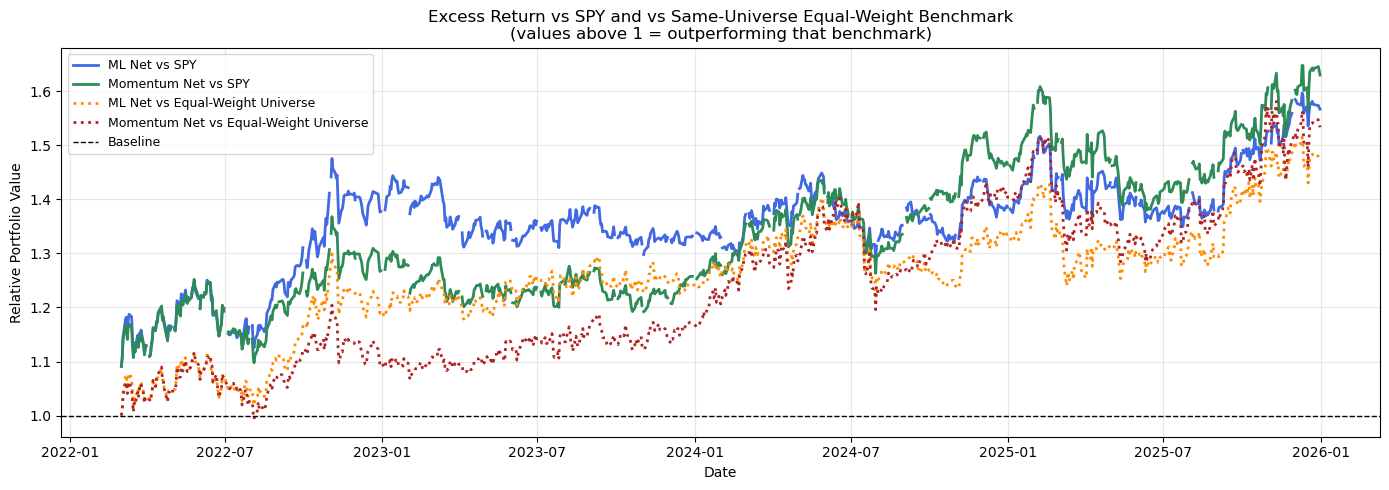

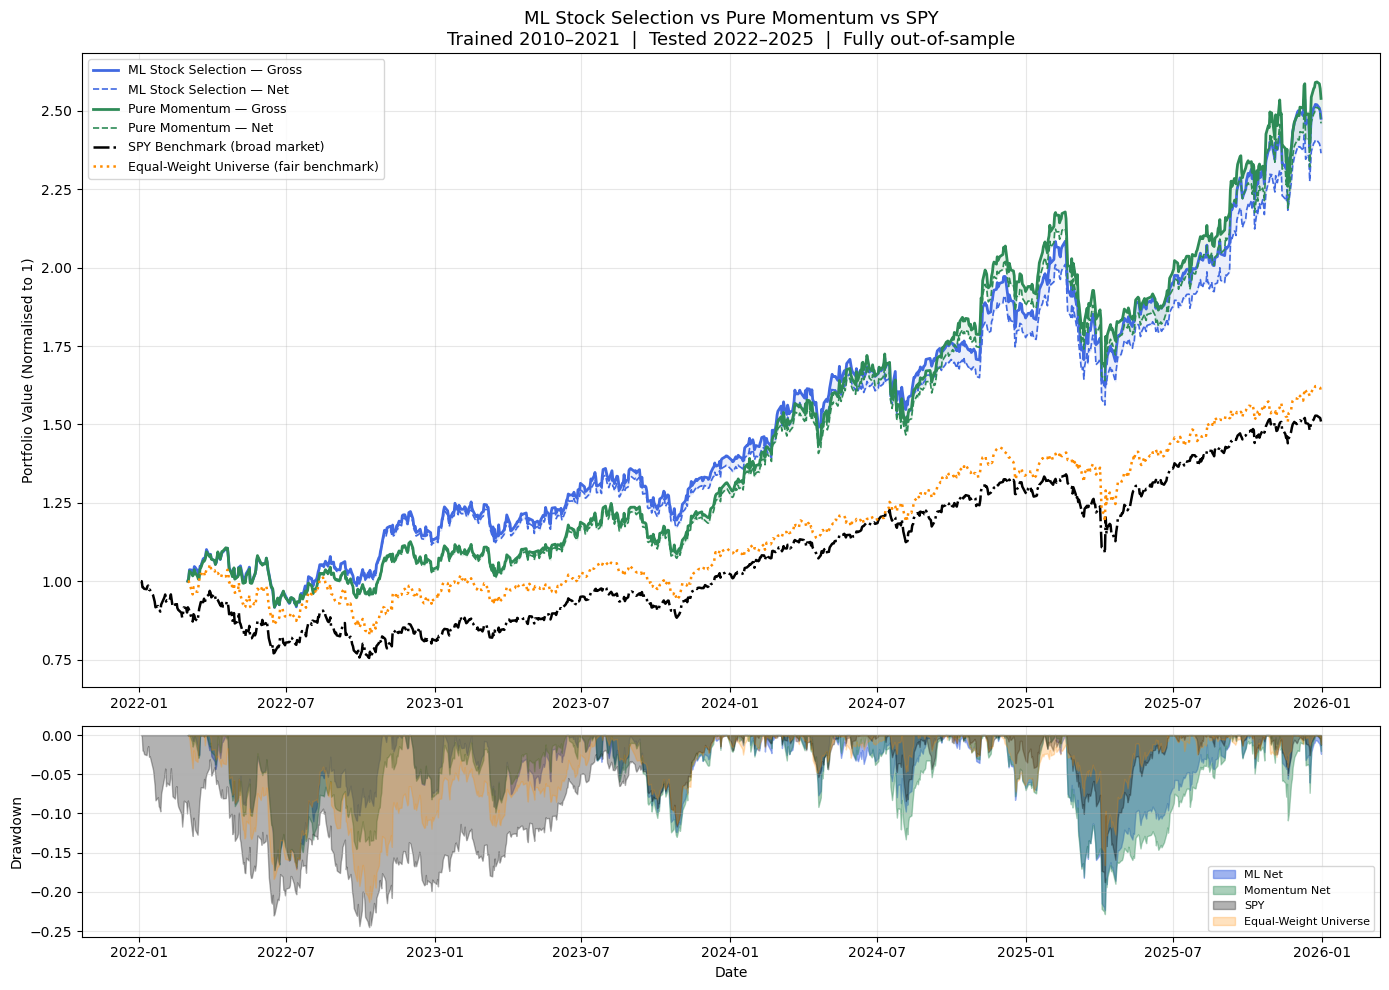


Done. Chart saved to backtest_result.png


In [29]:
#define cumulative value by cumulative returns
def to_cum(r):
    c = (1 + r).cumprod()
    return c / c.iloc[0]

#calculate drawdown
def calc_dd(c):
    return (c / c.cummax()) - 1

#convert the strategies into comulative curves
ml_gross_cum  = to_cum(ml_gross)
ml_net_cum    = to_cum(ml_net)
mom_gross_cum = to_cum(mom_gross)
mom_net_cum   = to_cum(mom_net)
spy_cum       = to_cum(spy_ret)
ew_cum        = to_cum(ew_ret)  # same-universe equal-weight benchmark

# Excess return over SPY (alpha isolation)
excess_ml  = ml_net_cum / spy_cum
excess_mom = mom_net_cum / spy_cum
excess_ml_ew  = ml_net_cum / ew_cum   # ML vs. same-universe benchmark (fair comparison)
excess_mom_ew = mom_net_cum / ew_cum  # Momentum vs. same-universe benchmark (fair comparison)

fig2, ax = plt.subplots(figsize=(14, 5))
ax.plot(excess_ml,  label="ML Net vs SPY",        color="royalblue", linewidth=2.0)
ax.plot(excess_mom, label="Momentum Net vs SPY",   color="seagreen",  linewidth=2.0)
ax.plot(excess_ml_ew,  label="ML Net vs Equal-Weight Universe",       color="darkorange", linewidth=2.0, linestyle=":")
ax.plot(excess_mom_ew, label="Momentum Net vs Equal-Weight Universe", color="firebrick",   linewidth=2.0, linestyle=":")
ax.axhline(1, color="black", linewidth=1.0, linestyle="--", label="Baseline")
ax.set_title("Excess Return vs SPY and vs Same-Universe Equal-Weight Benchmark\n(values above 1 = outperforming that benchmark)")
ax.set_ylabel("Relative Portfolio Value")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("excess_return.png", dpi=150, bbox_inches="tight")
plt.show()

#plotting the figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(ml_gross_cum,  label="ML Stock Selection — Gross",         color="royalblue", linewidth=2.0)
ax1.plot(ml_net_cum,    label="ML Stock Selection — Net",           color="royalblue", linewidth=1.2, linestyle="--")
ax1.plot(mom_gross_cum, label="Pure Momentum — Gross",              color="seagreen",  linewidth=2.0)
ax1.plot(mom_net_cum,   label="Pure Momentum — Net",                color="seagreen",  linewidth=1.2, linestyle="--")
ax1.plot(spy_cum,       label="SPY Benchmark (broad market)",       color="black",     linewidth=1.8, linestyle="-.")
ax1.plot(ew_cum,        label="Equal-Weight Universe (fair benchmark)", color="darkorange", linewidth=1.8, linestyle=":")

ax1.fill_between(ml_gross_cum.index,  ml_net_cum,  ml_gross_cum,  alpha=0.10, color="royalblue")
ax1.fill_between(mom_gross_cum.index, mom_net_cum, mom_gross_cum, alpha=0.10, color="seagreen")

ax1.set_title(
    f"ML Stock Selection vs Pure Momentum vs SPY\n"
    f"Trained {TRAIN_START[:4]}–{TRAIN_END[:4]}  |  Tested {BACKTEST_START[:4]}–{BACKTEST_END[:4]}  |  Fully out-of-sample",
    fontsize=13
)
ax1.set_ylabel("Portfolio Value (Normalised to 1)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.fill_between(ml_net_cum.index,  calc_dd(ml_net_cum),  alpha=0.5, color="royalblue", label="ML Net")
ax2.fill_between(mom_net_cum.index, calc_dd(mom_net_cum), alpha=0.4, color="seagreen",  label="Momentum Net")
ax2.fill_between(spy_cum.index,     calc_dd(spy_cum),     alpha=0.3, color="black",     label="SPY")
ax2.fill_between(ew_cum.index,      calc_dd(ew_cum),      alpha=0.25, color="darkorange", label="Equal-Weight Universe")
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("backtest_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nDone. Chart saved to backtest_result.png")



# **Performance of the Machine Learning Strategy**

The ML strategy modestly outperforms pure momentum on a risk-adjusted basis: a Sharpe ratio of 1.40 (gross) versus 1.34, and a shallower max drawdown (-22.2% vs. -22.7%), while returns are close (29.0% vs. 29.8% gross). Crucially, this isn't just a smoother equity curve by chance, across the out-of-sample evaluation period, the model shows a genuinely positive Information Coefficient (mean IC of 0.0545, IC IR of 0.2656), measured across every candidate it scored each month, not just the ones it picked. That's real evidence the model is extracting predictive signal, not just riding momentum's coattails.

Both ML and pure momentum comfortably beat SPY and a same-universe equal-weight benchmark, which confirms the outperformance isn't simply a function of which stocks are in the universe, active selection is adding value over holding everything equally.

Survivorship bias is still worth being upfront about: the universe, while broader than in earlier versions of this project, is not a full point-in-time reconstruction of a historical index, so companies that were delisted, went bankrupt, or fell out of the large-cap space along the way are still largely invisible to the backtest. This almost certainly inflates every strategy here - ML, momentum, and SPY alike - so these numbers are best read as a ceiling on realistic performance rather than something directly achievable.

Sharpe ratio is also a fairly blunt tool for this comparison, since it ignores correlations between stocks and can get unstable at low volatility. Mean-variance optimisation or risk parity would be a more principled way to weight the portfolio, though with this amount of data that brings its own overfitting risk.

# **ML vs Pure Momentum**

Pure momentum is a blunt instrument: buy whatever has gone up recently, without asking whether the move is stable or about to reverse. The ML layer adds real structure on top of that, drawing on multi-horizon returns, relative strength, volatility, and drawdown, with no single feature dominating, and the positive IC (0.0545) confirms this structure is picking up genuine signal, not just noise that happens to look good in one backtest. That's why it wins on risk-adjusted terms even without beating momentum on raw return: it's a more risk-aware way of expressing the same underlying trend-following idea.

Interestingly, momentum consistency (the fraction of positive months over the last 6 months) barely matters to the model (feature importance of 0.007). The real signal comes from combining multiple return horizons with relative strength and volatility, not from rewarding steady month-by-month gains specifically.


# **Overall Assessment**

The ML strategy is the stronger version tested here. It's backed by a positive, validated skill metric (IC of 0.0545), not just a favourable-looking equity curve, and it translates that into better risk-adjusted returns and a shallower drawdown than momentum alone: a real edge, even if a modest one. An earlier version of this project also tested six-monthly rolling retraining; on this broader universe it produced an IC essentially identical to the static model's and didn't improve portfolio-level performance, so it was dropped in favour of this simpler, fully static model. The core finding is that a feature-driven ML layer, validated with a proper skill metric rather than just an equity curve, produces a demonstrably more risk-aware strategy than momentum alone.

# **Limitations and Open Questions**

A few things temper how far these results should be taken. Results come from a single random seed and a single backtest path, so there's no direct measure of how much noise sits inside the reported Sharpe ratio or IC. The rel_strength feature is measured against the same universe used everywhere else in the backtest, so any remaining survivorship bias in that universe leaks into a model input as well as into the backtest results themselves. None of this undermines the core comparison between strategies, but the absolute numbers, and the IC figure especially, are best treated as indicative of a real, modest edge rather than a fully validated one.

The stock universe is a sector-stratified sample of roughly 180 current S&P 500 constituents, with the largest name or two guaranteed per sector, rather than a small hand-picked list. This reduces the risk of arbitrarily missing large, currently-important companies. It does not, however, fix survivorship bias itself; see below.

# **Survivorship Bias**

The stock universe consists of large-cap US equities currently trading, backfilled to 2009. This introduces survivorship bias: delisted, acquired, or bankrupted companies aren't captured, which likely flatters absolute returns across every strategy tested, including SPY. A more rigorous version would use point-in-time index data (including delisted names), though that typically requires paid datasets (e.g. CRSP, Compustat) beyond what's freely available.

Rebuilding the universe as a sector-stratified sample of the current S&P 500, rather than a small hand-picked list, avoids arbitrarily missing important companies. It does not fix survivorship bias itself, since it's still built from companies in the index today.